# setup

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def scatter(a, b, log=False, log10=False, diag=True, ma=0, ax=None, c='black', s=1,
            label=None, alpha=1, aspect=False, cmap=None, return_scat_obj=False, args={}):
    # Scatters a vs b of ax (default plt). Can apply:
    #   -   log(x+1) transformation (optional)
    #   -   label (optional)
    #   -   color (default black)
    #   -   size of point (default 1)
    #   -   alpha factor (default 1)
    #   -   aspect ratio equal (optional)
    #   -   diagonal line from 0 to ma (if provided) or to max(a,b) (optional)

    ax_ = ax if ax is not None else plt
    if log:
        a = a+1
        b = b+1
        ax_.semilogx(base=2)
        ax_.semilogy(base=2)
    elif log10:
        a = a+1
        b = b+1
        ax_.semilogx(base=10)
        ax_.semilogy(base=10)
    if diag:
        if ma == 0: ma = np.max([a.max(), b.max()])
        ax_.plot([0, ma], [0, ma], linewidth=1, c='black')
    if type(c) is str or type(c) == np.ndarray:
        scat = ax_.scatter(a, b, s=s, c=c, alpha=alpha, label=label, cmap=cmap, **args)
    else:
        scat = ax_.scatter(a, b, s=s, color=c, alpha=alpha, label=label, cmap=cmap, **args)
    if aspect:
        if ax is None: ax_.gca().set_aspect('equal')
        else: ax_.set_aspect('equal')
    if return_scat_obj: return ax_, scat
    else: return ax_



def add_labels(title=None, xlabel=None, ylabel=None, xlim=None, ylim=None,
               xticks=None, xticklabels=None, xtickrotation=None,
               yticks=None, yticklabels=None, ytickrotation=None,
               aspect=False, legend=False, ax=None):
    # Applies labels (if provided)

    if ax is None or ax is plt:
        if title is not None: plt.title(title)
        if xlabel is not None: plt.xlabel(xlabel)
        if ylabel is not None: plt.ylabel(ylabel)
        if xlim is not None: plt.xlim(xlim)
        if ylim is not None: plt.ylim(ylim)
        if xticks is not None:
            if xtickrotation is not None: plt.xticks(xticks, xticklabels, rotation=xtickrotation)
            else: plt.xticks(xticks, xticklabels)
        if yticks is not None:
            if ytickrotation is not None: plt.yticks(yticks, yticklabels, rotation=ytickrotation)
            else: plt.yticks(yticks, yticklabels)
        if aspect: plt.gca().set_aspect('equal')
        if legend: plt.legend()
        return plt
    else:
        if title is not None: ax.set_title(title)
        if xlabel is not None: ax.set_xlabel(xlabel)
        if ylabel is not None: ax.set_ylabel(ylabel)
        if xlim is not None: ax.set_xlim(xlim)
        if ylim is not None: ax.set_ylim(ylim)
        if xticks is not None: ax.set_xticks(xticks)
        if yticks is not None: ax.set_yticks(yticks)
        if xticklabels is not None:
            if xtickrotation is not None: ax.set_xticklabels(xticklabels, rotation=xtickrotation)
            else: ax.set_xticklabels(xticklabels)
        if yticklabels is not None:
            if ytickrotation is not None: ax.set_yticklabels(yticklabels, rotation=ytickrotation)
            else: ax.set_yticklabels(yticklabels)
        if aspect: ax.set_aspect('equal')
        if legend: ax.legend()
        return ax


def show(title=None, xlabel=None, ylabel=None, xlim=None, ylim=None, aspect=False,
         fig=plt, figname=None, tight_layout=True, dpi=300,
         savefig=True, showfig=True, legend=False, savepdf=False):
    # Finishes plot:
    #   -   Applies labels (if provided)
    #   -   Applies legend and tight_layout (optional)
    #   -   Saves to figname (optional)
    #   -   Shows fig (optional - otherwise delete it)

    if type(fig) is plt.Figure and title is not None: fig.suptitle(title)
    if type(fig) is not plt.Figure:
        add_labels(title=title, xlabel=xlabel, ylabel=ylabel, xlim=xlim, ylim=ylim, aspect=aspect, ax=None)
    else:
        add_labels(xlabel=xlabel, ylabel=ylabel, aspect=aspect, ax=None)

    if legend: plt.legend()
    if tight_layout: fig.tight_layout()
    if savefig and figname is not None: fig.savefig(figname.parent/f'{figname.name}.png', dpi=dpi)
    if savepdf and figname is not None: fig.savefig(figname.parent/f'{figname.name}.pdf')
    if showfig: plt.show()
    else: fig.clf()


# generate means

In [16]:
n_genes = 1000

# healthy profile (genes 0-499 are active)
mean_healthy = np.zeros(n_genes)
mean_healthy[:500] = 100

# disease A profile (genes 500-749 are active)
mean_disease_a = np.zeros(n_genes)
mean_disease_a[500:749] = 100

# disease B profile (genes 750-999 are active)
mean_disease_b = np.zeros(n_genes)
mean_disease_b[750:999] = 100

mean_healthy.shape, mean_disease_a.shape, mean_disease_b.shape

((1000,), (1000,), (1000,))

# generate data

In [17]:
n_healthy_samples = 200
n_disease_a_samples = 150
n_disease_b_samples = 150

bio_noise = 0.1

# healthy pool
healthy_part = np.random.normal(mean_healthy[:, None], bio_noise, size=(n_genes, n_healthy_samples + n_disease_a_samples + n_disease_b_samples)).clip(min=0)
disease_a_part = np.random.normal(mean_disease_a[:, None], bio_noise, size=(n_genes, n_disease_a_samples)).clip(min=0)
disease_b_part = np.random.normal(mean_disease_b[:, None], bio_noise, size=(n_genes, n_disease_b_samples)).clip(min=0)

healthy_part.shape, disease_a_part.shape, disease_b_part

((1000, 500),
 (1000, 150),
 array([[4.21853268e-02, 7.10526113e-02, 6.04835061e-02, ...,
         0.00000000e+00, 3.86292632e-02, 5.36488619e-02],
        [1.33358827e-01, 0.00000000e+00, 0.00000000e+00, ...,
         1.03132941e-01, 0.00000000e+00, 0.00000000e+00],
        [1.07019471e-02, 0.00000000e+00, 4.06225231e-02, ...,
         0.00000000e+00, 1.82331462e-01, 0.00000000e+00],
        ...,
        [9.98338863e+01, 1.00040805e+02, 1.00007158e+02, ...,
         9.99261553e+01, 1.00046474e+02, 9.99850182e+01],
        [9.98508878e+01, 1.00014154e+02, 9.99928697e+01, ...,
         1.00005751e+02, 1.00104052e+02, 1.00048994e+02],
        [2.22238219e-02, 7.75865548e-02, 0.00000000e+00, ...,
         3.23032326e-02, 1.31710942e-01, 0.00000000e+00]],
       shape=(1000, 150)))

# 0.5 theta

In [18]:
# isolate pure healthy samples
healthy_data = healthy_part[:, :n_healthy_samples]

# slice the remaining 300 into two chunks of 150
healthy_for_a = healthy_part[:, n_healthy_samples : n_healthy_samples + n_disease_a_samples]
healthy_for_b = healthy_part[:, n_healthy_samples + n_disease_a_samples :]

# craeting diseases a and b with theta = 0.5
disease_a_data_theta05 = 0.5 * healthy_for_a + 0.5 * disease_a_part
disease_b_data_theta05 = 0.5 * healthy_for_b + 0.5 * disease_b_part

healthy_data.shape, disease_a_data_theta05.shape, disease_b_data_theta05.shape

((1000, 200), (1000, 150), (1000, 150))

## Uniform Theta

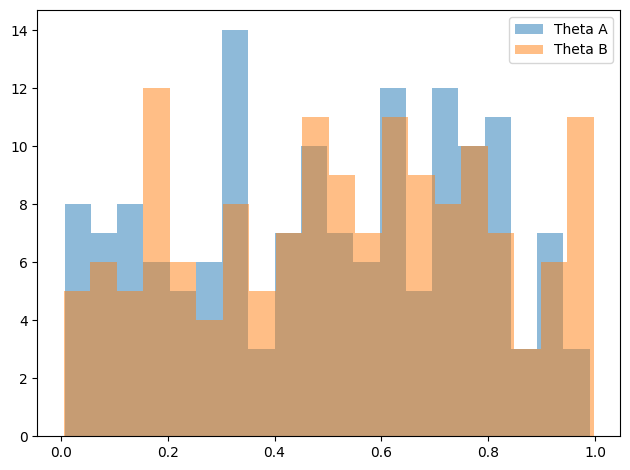

((1000, 150), (1000, 150))

In [19]:
# generate uniform theta values fro both diseases
theta_a = np.random.uniform(0, 1, n_disease_a_samples)
theta_b = np.random.uniform(0, 1, n_disease_b_samples)

# show histograms to verify
plt.hist(theta_a, bins=20, alpha=0.5, label='Theta A')
plt.hist(theta_b, bins=20, alpha=0.5, label='Theta B')
show(legend=True)

# mix using the continuous theta values
disease_a_data_uniform_theta = (1 - theta_a) * healthy_for_a + theta_a * disease_a_part
disease_b_data_uniform_theta = (1 - theta_b) * healthy_for_b + theta_b * disease_b_part
disease_a_data_uniform_theta.shape, disease_b_data_uniform_theta.shape

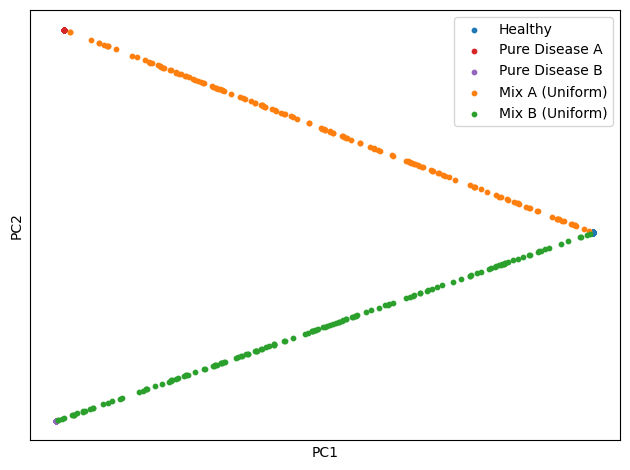

In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

# 1. Combine all the new datasets (transposed so samples are rows)
all_data = np.concatenate([
    healthy_data.T, 
    disease_a_part.T, 
    disease_b_part.T, 
    disease_a_data_uniform_theta.T, 
    disease_b_data_uniform_theta.T
], axis=0)

embedding = pca.fit_transform(all_data)

# 2. Setup dynamic indices for clean slicing
idx1 = n_healthy_samples
idx2 = idx1 + n_disease_a_samples
idx3 = idx2 + n_disease_b_samples
idx4 = idx3 + n_disease_a_samples

# 3. Slice the embedding back into groups
h_emb = embedding[:idx1]
pure_a_emb = embedding[idx1:idx2]
pure_b_emb = embedding[idx2:idx3]
mix_a_emb = embedding[idx3:idx4]
mix_b_emb = embedding[idx4:]

# 4. Plot the "Y-shape" trajectory
scatter(h_emb[:, 0], h_emb[:, 1], s=10, diag=0, c='tab:blue', label='Healthy')
scatter(pure_a_emb[:, 0], pure_a_emb[:, 1], s=10, diag=0, c='tab:red', label='Pure Disease A')
scatter(pure_b_emb[:, 0], pure_b_emb[:, 1], s=10, diag=0, c='tab:purple', label='Pure Disease B')
scatter(mix_a_emb[:, 0], mix_a_emb[:, 1], s=10, diag=0, c='tab:orange', label='Mix A (Uniform)')
scatter(mix_b_emb[:, 0], mix_b_emb[:, 1], s=10, diag=0, c='tab:green', label='Mix B (Uniform)')

add_labels(xticks=[], yticks=[])
show(xlabel='PC1', ylabel='PC2', legend=1)

# Adding noise

In [21]:
# add technical noise (e.g., std = 2.0)
tech_noise = 2.0

healthy_final = (healthy_data + np.random.normal(0, tech_noise, healthy_data.shape)).clip(min=0)

# theta 0.5
mix_a_final_05_theta = (disease_a_data_theta05 + np.random.normal(0, tech_noise, disease_a_data_theta05.shape)).clip(min=0)
mix_b_final_05_theta = (disease_b_data_theta05 + np.random.normal(0, tech_noise, disease_b_data_theta05.shape)).clip(min=0)

# uniform theta
mix_a_final_unif_theta = (disease_a_data_uniform_theta + np.random.normal(0, tech_noise, disease_a_data_uniform_theta.shape)).clip(min=0)
mix_b_final_unif_theta = (disease_b_data_uniform_theta + np.random.normal(0, tech_noise, disease_b_data_uniform_theta.shape)).clip(min=0)

# save data

In [22]:
import pandas as pd

gene_index = [f'Gene{i}' for i in range(n_genes)]

# save healthy data
healthy_data_df = pd.DataFrame(
    healthy_final, index=gene_index,
    columns=[f'Healthy-Sample{i}' for i in range(n_healthy_samples)]
)
healthy_data_df.to_csv('healthy_data.csv')

### Uniform theta

In [23]:
# disease a
disease_a_uniform_df = pd.DataFrame(
    mix_a_final_unif_theta, index=gene_index,
    columns=[f'DiseaseA-Sample{i}' for i in range(n_disease_a_samples)]
)
disease_a_uniform_df.to_csv('disease_a_data_uniform_theta.csv')

# disease b
disease_b_uniform_df = pd.DataFrame(
    mix_b_final_unif_theta, index=gene_index,
    columns=[f'DiseaseB-Sample{i}' for i in range(n_disease_b_samples)]
)
disease_b_uniform_df.to_csv('disease_b_data_uniform_theta.csv')

### 0.5 theta

In [24]:
# disease a
disease_a_05_theta_df = pd.DataFrame(
    mix_a_final_05_theta, index=gene_index,
    columns=[f'DiseaseA-Sample{i}' for i in range(n_disease_a_samples)]
)
disease_a_05_theta_df.to_csv('disease_a_data_05_theta.csv')

# disease b
disease_b_05_theta_df = pd.DataFrame(
    mix_b_final_05_theta, index=gene_index,
    columns=[f'DiseaseB-Sample{i}' for i in range(n_disease_b_samples)]
)
disease_b_05_theta_df.to_csv('disease_b_data_05_theta.csv')

In [25]:
# Save Ground Truth Theta Values (Uniform Samples)
theta_truth = pd.DataFrame({
    'Sample_ID': [f'DiseaseA-Sample{i}' for i in range(n_disease_a_samples)] + 
                 [f'DiseaseB-Sample{i}' for i in range(n_disease_b_samples)],
    'theta_value': np.concatenate([theta_a, theta_b]),
    'Disease_Type': ['A'] * n_disease_a_samples + ['B'] * n_disease_b_samples
})
theta_truth.to_csv('syn_theta_values.csv', index=False)

# Save Base Mean Profiles
pd.DataFrame({
    'Healthy_Mean': mean_healthy,
    'DiseaseA_Mean': mean_disease_a,
    'DiseaseB_Mean': mean_disease_b
}, index=[f'Gene{i}' for i in range(n_genes)]).to_csv('base_profiles_truth.csv')

In [26]:
import pandas as pd
from pathlib import Path
import shutil

# 1. Setup the complex data directory
# complex_data_dir = Path('data/synthetic_complex')
# complex_data_dir.mkdir(parents=True, exist_ok=True)

def merge_expression_sets(file_a, file_b, output_name):
    """Merges expression CSVs, prefixes columns, and adds a disease_type row."""
    df_a = pd.read_csv(file_a, index_col=0)
    df_b = pd.read_csv(file_b, index_col=0)
    
    # Rename columns so 'Sample0' becomes 'A_Sample0' and 'B_Sample0'
    df_a.columns = [f"{col}" for col in df_a.columns]
    df_b.columns = [f"{col}" for col in df_b.columns]
    
    combined_df = pd.concat([df_a, df_b], axis=1)
    
    # Add the disease_type row at the bottom
    combined_df.loc['disease_type'] = ['A'] * len(df_a.columns) + ['B'] * len(df_b.columns)
    
    combined_df.to_csv(output_name)
    print(f"✅ Combined Expression: {output_name} {combined_df.shape}")
    return df_a.columns.tolist(), df_b.columns.tolist()


# theta 0.5
cols_a_05, cols_b_05 = merge_expression_sets(
    'disease_a_data_05_theta.csv', 
    'disease_b_data_05_theta.csv', 
    'disease_data_theta05.csv'
)

# uniform theta
cols_a_uni, cols_b_uni = merge_expression_sets(
    'disease_a_data_uniform_theta.csv', 
    'disease_b_data_uniform_theta.csv', 
    'disease_data_uniform_theta.csv'
)

✅ Combined Expression: disease_data_theta05.csv (1001, 300)
✅ Combined Expression: disease_data_uniform_theta.csv (1001, 300)
